In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder, PowerTransformer
#from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE, MutualInfoClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import VarianceThreshold

In [2]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('ggplot')
sns.set_palette("husl")

# Define Column Names for NSL-KDD (Standard List)
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]

In [3]:
# Load Preprocessed NSL-KDD Dataset

import pandas as pd
import os

DATA_DIR = "../data/labeled_data"

train_path = os.path.join(DATA_DIR, "KDDTrain_data.csv")
test_path  = os.path.join(DATA_DIR, "KDDTest_data.csv")

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)

Train Shape: (125973, 43)
Test Shape: (22544, 43)


In [4]:
df_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
# Attack Category Mapping
attack_mapping = {
    'normal': 'normal',
    
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS',
    
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe',
    'nmap': 'Probe', 'portsweep': 'Probe',
    
    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L',
    'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezclient': 'R2L',
    'warezmaster': 'R2L', 'spy': 'R2L',
    
    # U2R
    'buffer_overflow': 'U2R', 'rootkit': 'U2R',
    'loadmodule': 'U2R', 'perl': 'U2R'
}

df_train['attack_class'] = df_train['class'].map(attack_mapping)
df_test['attack_class']  = df_test['class'].map(attack_mapping)

df_train['attack_class'].value_counts()

attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

In [6]:

# Feature Grouping

categorical_features = ['protocol_type','service','flag']
binary_features = ['land','logged_in','is_host_login','is_guest_login']

numerical_features = [
    col for col in df_train.columns 
    if col not in categorical_features + binary_features + ['class','difficulty_level','attack_class']
]

print("Categorical:", len(categorical_features))
print("Binary:", len(binary_features))
print("Numerical:", len(numerical_features))

Categorical: 3
Binary: 4
Numerical: 34


In [7]:
print("\nTotal Missing Values in Test Data:", df_test.isnull().sum().sum())


Total Missing Values in Test Data: 3750


In [8]:
from sklearn.ensemble import IsolationForest

# Isolation Forest Outlier Detection

iso = IsolationForest(contamination=0.01, random_state=42)

df_train['is_outlier'] = iso.fit_predict(df_train[numerical_features])

print("Outliers detected:", (df_train['is_outlier'] == -1).sum())

Outliers detected: 1256


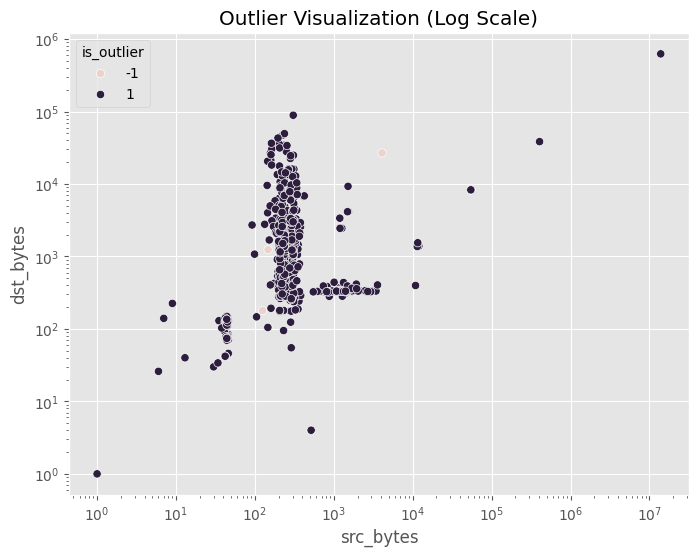

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_train[::100],
    x='src_bytes',
    y='dst_bytes',
    hue='is_outlier'
)

plt.xscale('log')
plt.yscale('log')
plt.title("Outlier Visualization (Log Scale)")
plt.show()

In [10]:

# Skewness Before Transformation

skewed_cols = ['duration','src_bytes','dst_bytes']

print("Skewness Before:")
print(df_train[skewed_cols].skew())

Skewness Before:
duration      11.880230
src_bytes    190.669347
dst_bytes    290.052911
dtype: float64


In [11]:
# Apply Log1p Transformation

for col in skewed_cols:
    df_train[f'log_{col}'] = np.log1p(df_train[col])
    df_test[f'log_{col}']  = np.log1p(df_test[col])

print("Skewness After:")
print(df_train[[f'log_{col}' for col in skewed_cols]].skew())

Skewness After:
log_duration     5.338451
log_src_bytes    0.310643
log_dst_bytes    0.493738
dtype: float64


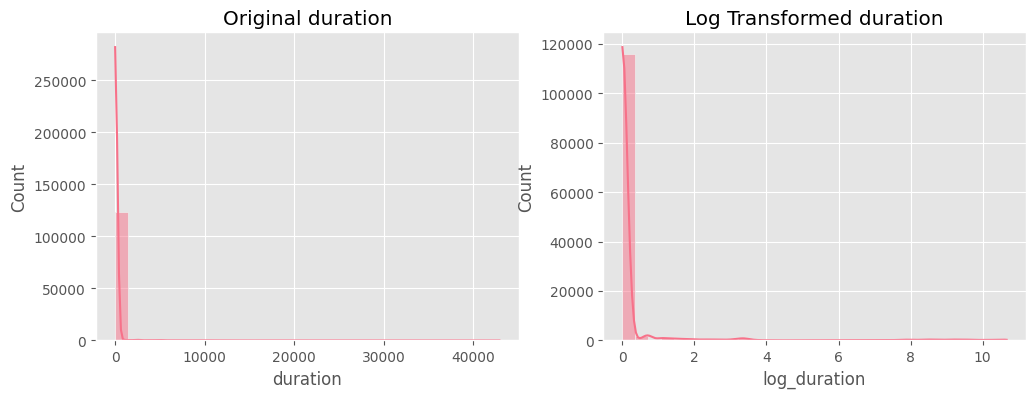

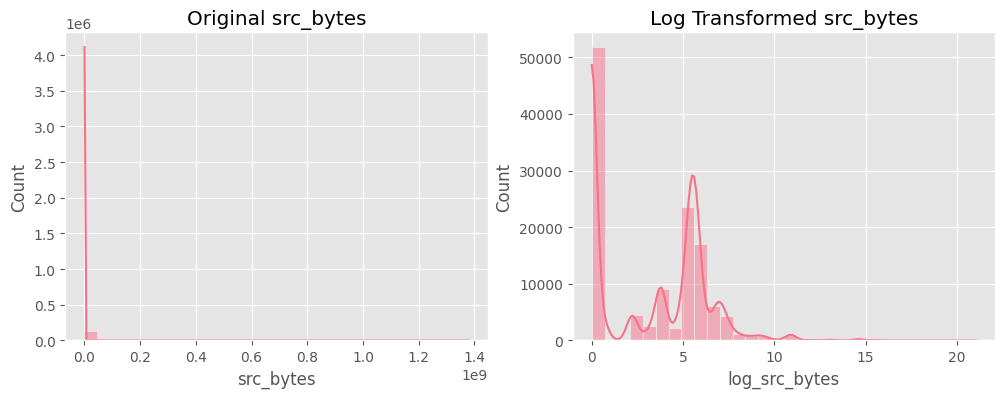

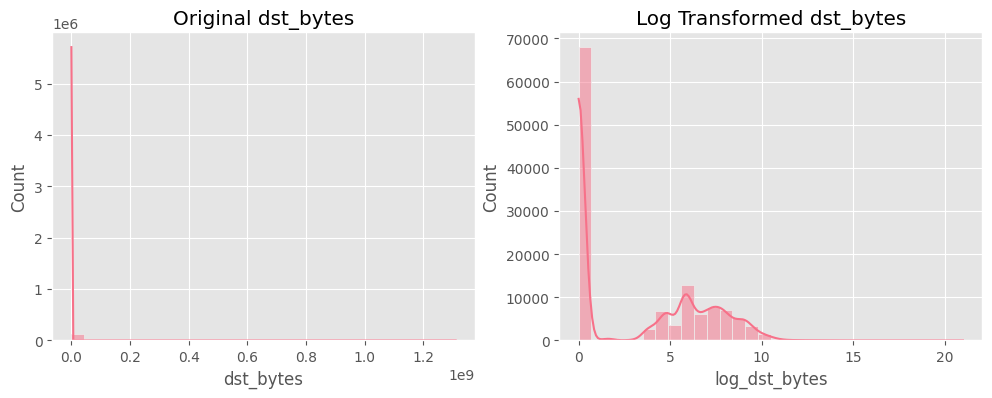

In [12]:
for col in skewed_cols:
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    
    sns.histplot(df_train[col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"Original {col}")
    
    sns.histplot(df_train[f'log_{col}'], bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"Log Transformed {col}")
    
    plt.show()

In [13]:

df_train['total_bytes'] = df_train['src_bytes'] + df_train['dst_bytes']

df_train['src_bytes_ratio'] = df_train['src_bytes'] / (df_train['total_bytes'] + 1e-5)

df_train['packet_rate'] = df_train['count'] / (df_train['duration'] + 1e-5)

df_train['byte_difference'] = abs(df_train['src_bytes'] - df_train['dst_bytes'])

error_flags = ['S0','S1','S2','S3','REJ']
df_train['is_error_flag'] = df_train['flag'].apply(lambda x: 1 if x in error_flags else 0)

df_train['same_service_interaction'] = (
    df_train['same_srv_rate'] * df_train['dst_host_same_srv_rate']
)

df_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,is_outlier,log_duration,log_src_bytes,log_dst_bytes,total_bytes,src_bytes_ratio,packet_rate,byte_difference,is_error_flag,same_service_interaction
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,1,0.0,6.198479,0.000000,491,1.000000,200000.0,491,0,0.170
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.0,4.990433,0.000000,146,1.000000,1300000.0,146,0,0.000
2,0,tcp,private,S0,0,0,0,0,0,0,...,1,0.0,0.000000,0.000000,0,0.000000,12300000.0,0,1,0.005
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1,0.0,5.451038,9.006264,8385,0.027668,500000.0,7921,0,1.000
4,0,tcp,http,SF,199,420,0,0,0,0,...,1,0.0,5.298317,6.042633,619,0.321486,3000000.0,221,0,1.000


In [19]:
df_test['total_bytes'] = df_test['src_bytes'] + df_test['dst_bytes']

df_test['src_bytes_ratio'] = df_test['src_bytes'] / (df_test['total_bytes'] + 1e-5)

df_test['packet_rate'] = df_test['count'] / (df_test['duration'] + 1e-5)

df_test['byte_difference'] = abs(df_test['src_bytes'] - df_test['dst_bytes'])

error_flags = ['S0','S1','S2','S3','REJ']

df_test['is_error_flag'] = df_test['flag'].isin(error_flags).astype(int)

df_test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,difficulty_level,attack_class,log_duration,log_src_bytes,log_dst_bytes,total_bytes,src_bytes_ratio,packet_rate,byte_difference,is_error_flag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,21,DoS,0.000000,0.000000,0.000000,0,0.0,2.290000e+07,0,1
1,0,tcp,private,REJ,0,0,0,0,0,0,...,21,DoS,0.000000,0.000000,0.000000,0,0.0,1.360000e+07,0,1
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,21,normal,1.098612,9.471473,0.000000,12983,1.0,4.999975e-01,12983,0
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,15,NaN,0.000000,3.044522,0.000000,20,1.0,1.000000e+05,20,0
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,11,NaN,0.693147,0.000000,2.772589,15,0.0,9.999900e-01,15,0


In [14]:
# One-Hot Encoding

from sklearn.preprocessing import OneHotEncoder

# Columns to encode
cols_to_encode = ['protocol_type', 'flag']

# Initialize encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit ONLY on training data
ohe.fit(df_train[cols_to_encode])

# Transform training data
train_encoded = pd.DataFrame(
    ohe.transform(df_train[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_train.index
)

# Transform test data
test_encoded = pd.DataFrame(
    ohe.transform(df_test[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_test.index
)

# Concatenate encoded columns back to original dataset
df_train_encoded = pd.concat([df_train, train_encoded], axis=1)
df_test_encoded  = pd.concat([df_test, test_encoded], axis=1)

# Drop original categorical columns
df_train_encoded.drop(columns=cols_to_encode, inplace=True)
df_test_encoded.drop(columns=cols_to_encode, inplace=True)

print("Train Shape After Encoding:", df_train_encoded.head())
print("Test Shape After Encoding:", df_test_encoded.head())

Train Shape After Encoding:    duration   service  src_bytes  dst_bytes  land  wrong_fragment  urgent  \
0         0  ftp_data        491          0     0               0       0   
1         0     other        146          0     0               0       0   
2         0   private          0          0     0               0       0   
3         0      http        232       8153     0               0       0   
4         0      http        199        420     0               0       0   

   hot  num_failed_logins  logged_in  ...  flag_REJ  flag_RSTO  flag_RSTOS0  \
0    0                  0          0  ...       0.0        0.0          0.0   
1    0                  0          0  ...       0.0        0.0          0.0   
2    0                  0          0  ...       0.0        0.0          0.0   
3    0                  0          1  ...       0.0        0.0          0.0   
4    0                  0          1  ...       0.0        0.0          0.0   

   flag_RSTR  flag_S0  flag_S1  fl

In [15]:
df_train_encoded.columns

Index(['duration', 'service', 'src_bytes', 'dst_bytes', 'land',
       'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'root_shell', 'su_attempted', 'num_root',
       'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class',
       'difficulty_level', 'attack_class', 'is_outlier', 'log_duration',
       'log_src_bytes', 'log_dst_bytes', 'total_bytes', 'src_bytes_ratio',
       'packet_rate', 'byte_difference', 'is_error_flag'

In [21]:
df_train_encoded.drop(columns=['protocol_type','flag','service'], inplace=True, errors='ignore')
df_test_encoded.drop(columns=['protocol_type','flag','service'], inplace=True, errors='ignore')

In [ ]:
def engineer_features(df):
    df_eng = df.copy()
    
    # 1. Total Bytes
    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']
    
    # 2. Byte Ratio (Handle division by zero)
    df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1e-5)
    
    # 3. Load / Packet Rate
    # If duration is 0, we assume it's a single instantaneous event (rate = count)
    df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1e-5)
    
    # 4. Title: Flow Asymmetry
    df_eng['byte_diff'] = abs(df_eng['src_bytes'] - df_eng['dst_bytes'])
    
    # 5. Flag interactions (example: is it an error flag?)
    error_flags = ['S0', 'S1', 'S2', 'S3', 'REJ']
    df_eng['is_error_flag'] = df_eng['flag'].isin(error_flags).astype(int)
    
    # 6. Critical Host Interaction
    # Interaction between 'same_srv_rate' and 'dst_host_same_srv_rate'
    df_eng['same_srv_interaction'] = df_eng['same_srv_rate'] * df_eng['dst_host_same_srv_rate']
    
    return df_eng

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("New Feature Set Head:")
print(df_train[['src_bytes_ratio', 'packet_rate', 'is_error_flag', 'same_srv_interaction']].head())

In [ ]:
df_train['service']

In [30]:
corr_matrix = df_train_encoded.select_dtypes(include=[np.number]).corr().abs()

# Upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find highly correlated features
threshold = 0.95
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Features to drop due to high correlation (>0.95): {to_drop}")

# Drop from train
df_train_reduce = df_train_encoded.drop(columns=to_drop, errors='ignore')

# Drop only columns that exist in test
cols_dropped_from_test = [c for c in to_drop if c in df_test_encoded.columns]
df_test_reduce = df_test_encoded.drop(columns=cols_dropped_from_test)

# Align test dataset columns with train dataset
df_test_reduce = df_test_reduce.reindex(columns=df_train_reduce.columns, fill_value=0)

# Verify shapes
print("Train shape:", df_train_reduce.shape)
print("Test shape:", df_test_reduce.shape)

Features to drop due to high correlation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_difference', 'same_service_interaction', 'flag_S0']
Train shape: (125973, 55)
Test shape: (22544, 55)


In [33]:
print(df_train_reduce['attack_class'].value_counts())

attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [32]:
print(df_train_reduce['class'].value_counts())

class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


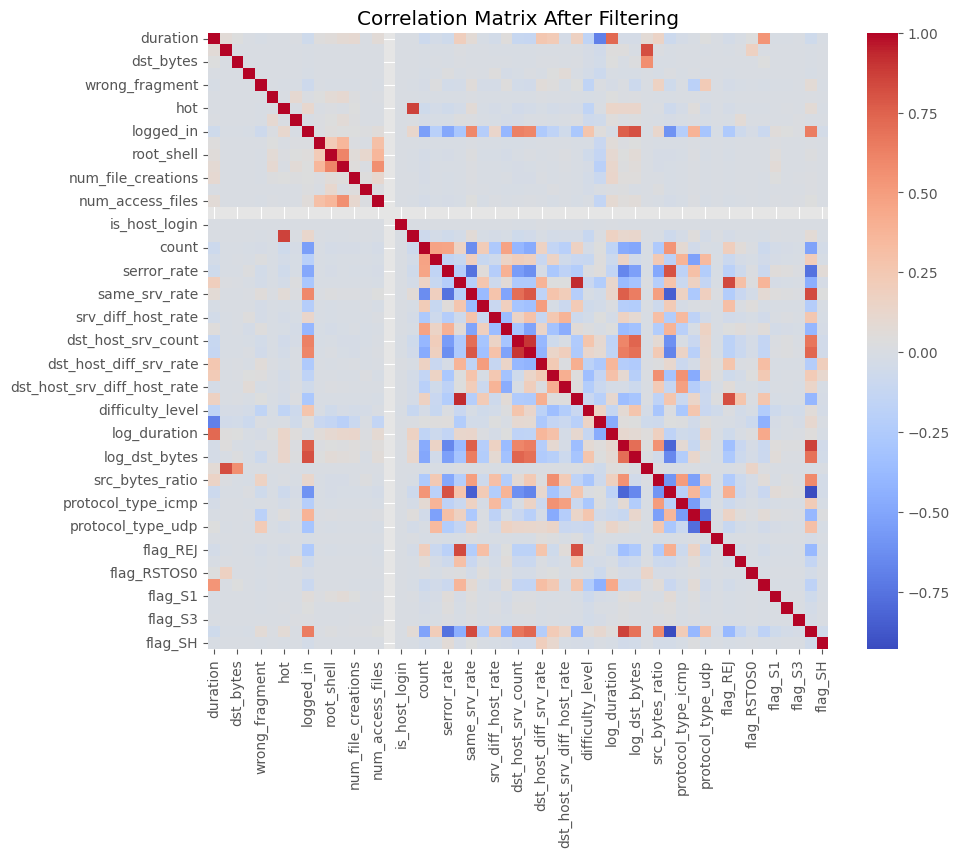

In [37]:
plt.figure(figsize=(10,8))

numeric_df = df_train_reduce.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Matrix After Filtering")
plt.show()

In [39]:
from sklearn.preprocessing import RobustScaler

exclude_cols = ['class','attack_class','difficulty_level','is_outlier']

# Select columns to scale
features_to_scale = [col for col in df_train_reduce.columns if col not in exclude_cols]

scaler = RobustScaler()
# Fit on train
df_train_reduce[features_to_scale] = scaler.fit_transform(df_train_reduce[features_to_scale])

# Transform test (NOT fit_transform)
df_test_reduce[features_to_scale] = scaler.transform(df_test_reduce[features_to_scale])

print(df_train_reduce[features_to_scale[0:5]].describe())

           duration     src_bytes     dst_bytes           land  wrong_fragment
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   125973.000000
mean      287.14465  1.649375e+02  3.833162e+01       0.000198        0.022687
std      2604.51531  2.126932e+04  7.793157e+03       0.014086        0.253530
min         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
25%         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
50%         0.00000  0.000000e+00  0.000000e+00       0.000000        0.000000
75%         0.00000  8.405797e-01  1.000000e+00       0.000000        0.000000
max     42908.00000  4.999869e+06  2.538638e+06       1.000000        3.000000


In [41]:
print(df_train_reduce[features_to_scale[0:5]])

        duration  src_bytes  dst_bytes  land  wrong_fragment
0            0.0   1.619565   0.000000   0.0             0.0
1            0.0   0.369565   0.000000   0.0             0.0
2            0.0  -0.159420   0.000000   0.0             0.0
3            0.0   0.681159  15.800388   0.0             0.0
4            0.0   0.561594   0.813953   0.0             0.0
...          ...        ...        ...   ...             ...
125968       0.0  -0.159420   0.000000   0.0             0.0
125969       8.0   0.221014   0.281008   0.0             0.0
125970       0.0   7.923913   0.744186   0.0             0.0
125971       0.0  -0.159420   0.000000   0.0             0.0
125972       0.0   0.387681   0.000000   0.0             0.0

[125973 rows x 5 columns]


In [46]:
!pip install imbalanced-learn

In [49]:
# Target column
target_col = 'attack_class'

# Separate features and label
X = df_train_reduce.drop(columns=['label','attack_class','difficulty_level'], errors='ignore')
y = df_train_reduce[target_col]

# Ensure only numeric columns
X = X.select_dtypes(include=['number'])

# Handle missing values
X = X.fillna(0)

print("Class Distribution BEFORE SMOTE:")
print(y.value_counts())

Class Distribution BEFORE SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


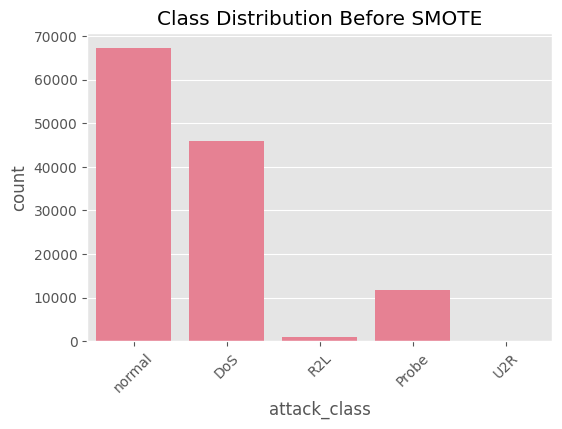

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution Before SMOTE")
plt.xticks(rotation=45)
plt.show()

In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Class Distribution AFTER SMOTE:")
print(y_resampled.value_counts())

Class Distribution AFTER SMOTE:
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


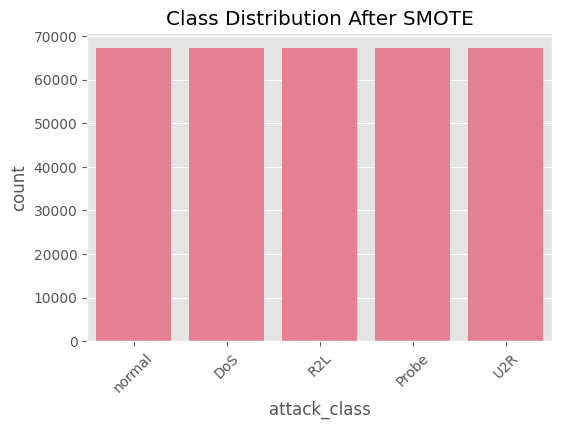

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.title("Class Distribution After SMOTE")
plt.xticks(rotation=45)
plt.show()

In [53]:
print("Original Dataset Shape:", X.shape)
print("After SMOTE Shape:", X_resampled.shape)

Original Dataset Shape: (125973, 52)
After SMOTE Shape: (336715, 52)


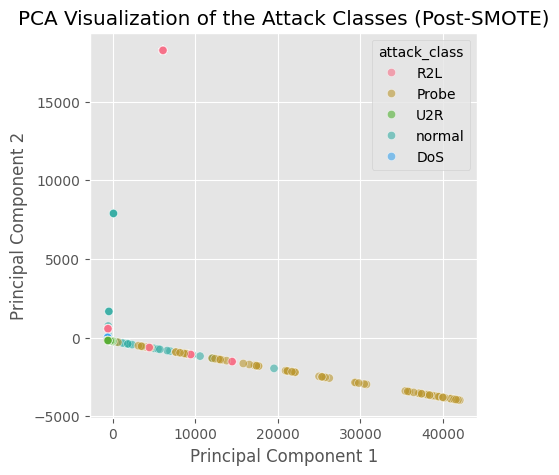

In [54]:
# Sample data for visualization
sample_idx = X_resampled.sample(5000, random_state=42).index

X_sample = X_resampled.loc[sample_idx]
y_sample = y_resampled.loc[sample_idx]

# Apply PCA for visualization
pca = PCA(n_components=2)

x_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(5,5))

sns.scatterplot(
    x=x_pca[:,0],
    y=x_pca[:,1],
    hue=y_sample,
    alpha=0.6
)

plt.title("PCA Visualization of the Attack Classes (Post-SMOTE)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [56]:
# Create processed folder and save dataset

import os
import pandas as pd

# Combine features and labels
processed_df = pd.concat([X_resampled, y_resampled], axis=1)

# Folder path
PROCESSED_DIR = "../data/processed"

# Create folder if it doesn't exist
os.makedirs(PROCESSED_DIR, exist_ok=True)

# File path
save_path = os.path.join(PROCESSED_DIR, "train_processed_advanced.csv")

# Save dataset
processed_df.to_csv(save_path, index=False)

print("Processed dataset saved at:", save_path)

Processed dataset saved at: ../data/processed\train_processed_advanced.csv
